# Code to find the Best Binders from AlphaFold Outputs

## Imports

In [85]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.


In [86]:
import pandas as pd
import glob
import os
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
import functools

## Configuration

In [87]:
INPUT_FOLDER = '../Local/AlphaFoldMetrics'
OUTPUT_FOLDER = os.path.join(INPUT_FOLDER, 'Analysis_Results')
METRIC_FILENAME_IDX = 2
TOP_N = 10  # Keep top N variants per category

# The names must match the suffix of your files (e.g., 'pLDDT' for 'analysis_results_pLDDT.xlsx')
IMPORTANT_METRICS = ['LpLDDT', 'PAE', 'ipTM'] 

## Configuration for final selection
# How many variants do you want per category? (Range: 2-4)
COUNT_PER_CATEGORY = 3

# Define your Targets of Interest
# Note: These strings must match the column names in your Excel files EXACTLY.
TARGET_1 = 'adam17'
TARGET_2 = 'mmp9'

# Define your Pairwise Negative Controls (The "Bad" target in the pair)
# Logic: Find variants better at Target 1 than Pair_Neg_1
PAIR_NEG_1 = 'adam10'  # for adam17 vs adam10
PAIR_NEG_2 = 'mmp2'    # for mmp9 vs mmp2

# DEFINE METRIC DIRECTIONS
# True = Higher is Better (e.g., pLDDT, Affinity, Stability)
# False = Lower is Better (e.g., RMSD, Energy, deltaG)
# The script defaults to True if the metric isn't listed here.
METRIC_DIRECTIONS = {
    'pLDDT': True,
    'LpLDDT': True,
    'PAE': False,
    'RMSD': False,
    'Energy': False,
    'ipTM': True,
    'dG': False
}

# STRUCTURAL FILTER (The "Folding" Check)
# Set to True to enable filtering variants that don't fold well
APPLY_STRUCTURAL_FILTER = True
STRUCTURAL_THRESHOLD = 0.80
STRUCTURAL_METRIC_KEY = 'ApTM' # Text to look for in raw filenames (e.g., "pTM" or "pLDDT")

## Run Analysis

### Find the Best Binders for each Metric

In [88]:
def get_direction(metric_name):
    """Returns True if Higher is Better, False otherwise."""
    return METRIC_DIRECTIONS.get(metric_name, True) # Default to True

def analyze_metric_group(metric_name, file_list):
    print(f"\n--- Processing Metric: {metric_name} ({len(file_list)} files) ---")
    
    higher_is_better = get_direction(metric_name)
    direction_str = "Higher is Better" if higher_is_better else "Lower is Better"
    print(f"Direction: {direction_str}")

    # 1. Load and Merge Data
    df_list = []
    for filename in file_list:
        try:
            temp_df = pd.read_excel(filename)
            # Fix merged cells (Forward Fill)
            temp_df.iloc[:, 0] = temp_df.iloc[:, 0].ffill()
            # Normalize cols
            temp_df.columns = [str(c).strip() for c in temp_df.columns]
            df_list.append(temp_df)
        except Exception as e:
            print(f"Error reading {os.path.basename(filename)}: {e}")

    if not df_list:
        return

    df = pd.concat(df_list, ignore_index=True)

    # 2. Identify Columns
    subgroup_col = df.columns[0]
    variant_col = df.columns[1]
    target_cols = df.columns[2:].tolist()

    # 3. Clean Data
    initial_len = len(df)
    for col in target_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=target_cols)
    if len(df) < initial_len:
        print(f"Dropped {initial_len - len(df)} rows due to missing data.")

    # Helper for getting Top/Bottom N
    def get_extreme_rows(group_df, sort_col, get_best=True):
        # Determine if we want largest or smallest based on logic
        # If Higher is Better AND we want Best -> nlargest
        # If Higher is Better AND we want Worst -> nsmallest
        # If Lower is Better AND we want Best -> nsmallest
        # If Lower is Better AND we want Worst -> nlargest
        
        if higher_is_better:
            if get_best: return group_df.nlargest(TOP_N, sort_col, keep='all')
            else:        return group_df.nsmallest(TOP_N, sort_col, keep='all')
        else:
            if get_best: return group_df.nsmallest(TOP_N, sort_col, keep='all')
            else:        return group_df.nlargest(TOP_N, sort_col, keep='all')

    # ==========================================
    # ANALYSIS 1: Best Variants per Target (Raw Score)
    # ==========================================
    results_best_raw = []
    for subgroup, group_df in df.groupby(subgroup_col):
        for target in target_cols:  # type: ignore
            if group_df.empty: continue
            
            top_rows = get_extreme_rows(group_df, target, get_best=True).copy()
            top_rows['Best_For_Target'] = target
            top_rows['Rank'] = range(1, len(top_rows) + 1)
            results_best_raw.append(top_rows)

    df_best_raw = pd.concat(results_best_raw) if results_best_raw else pd.DataFrame()

    # ==========================================
    # ANALYSIS 2: Best Specificity (One vs Rest)
    # ==========================================
    results_specificity = []
    for target in target_cols:
        other_targets = [t for t in target_cols if t != target] # type: ignore
        if not other_targets: continue 

        # Calculate Specificity Gap
        # Specificity is always "Higher is Better" (we want a large gap)
        if higher_is_better:
            spec_score = df[target] - df[other_targets].mean(axis=1)
        else:
            # If lower is better (e.g. Energy -50 is better than -10)
            # We want (Avg Others) - (Target). 
            # Ex: Others avg -10, Target -50. Gap = -10 - (-50) = 40. (Good gap)
            spec_score = df[other_targets].mean(axis=1) - df[target]
        
        col_name = f'Spec_Score_{target}'
        df[col_name] = spec_score

        for subgroup, group_df in df.groupby(subgroup_col): # type: ignore
            if group_df.empty: continue
            
            # Use nlargest because Gap is always "Higher is better"
            top_rows = group_df.nlargest(TOP_N, col_name, keep='all').copy()
            
            top_rows['Target_of_Interest'] = target
            top_rows['Specificity_Gap'] = top_rows[col_name]
            top_rows['Rank'] = range(1, len(top_rows) + 1)
            
            top_rows = top_rows.drop([c for c in top_rows.columns if 'Spec_Score' in str(c)], axis=1)
            results_specificity.append(top_rows)

    df_specificity = pd.concat(results_specificity) if results_specificity else pd.DataFrame()

    # ==========================================
    # ANALYSIS 3: Pairwise Specificity
    # ==========================================
    results_pairwise = []
    pairs = list(itertools.permutations(target_cols, 2))

    for target_a, target_b in pairs:
        if higher_is_better:
            gap = df[target_a] - df[target_b]
        else:
            gap = df[target_b] - df[target_a]
        
        col_name = f'Gap_{target_a}_vs_{target_b}'
        df[col_name] = gap

        for subgroup, group_df in df.groupby(subgroup_col): # type: ignore
            if group_df.empty: continue
            
            # Gap is always "Maximize distance"
            top_rows = group_df.nlargest(TOP_N, col_name, keep='all').copy()
            
            for i, (_, row) in enumerate(top_rows.iterrows()):
                output_data = {
                    subgroup_col: row[subgroup_col],
                    variant_col: row[variant_col],
                    'Primary_Target': target_a,
                    'Secondary_Target': target_b,
                    'Gap': row[col_name],
                    'Rank': i + 1,
                    f'Score_{target_a}': row[target_a],
                    f'Score_{target_b}': row[target_b]
                }
                results_pairwise.append(output_data)

    df_pairwise = pd.DataFrame(results_pairwise)

    # ==========================================
    # ANALYSIS 4 & 5: Overall Performance (Across All Targets)
    # ==========================================
    # Calculate Mean Score across all targets
    df['Mean_Score_Overall'] = df[target_cols].mean(axis=1)
    
    results_best_overall = []
    results_worst_overall = []

    for subgroup, group_df in df.groupby(subgroup_col):
        if group_df.empty: continue
        
        # Get Best Overall
        best_rows = get_extreme_rows(group_df, 'Mean_Score_Overall', get_best=True).copy()
        best_rows['Rank'] = range(1, len(best_rows) + 1)
        results_best_overall.append(best_rows)

        # Get Worst Overall
        worst_rows = get_extreme_rows(group_df, 'Mean_Score_Overall', get_best=False).copy()
        worst_rows['Rank'] = range(1, len(worst_rows) + 1)
        results_worst_overall.append(worst_rows)
    
    df_best_overall = pd.concat(results_best_overall) if results_best_overall else pd.DataFrame()
    df_worst_overall = pd.concat(results_worst_overall) if results_worst_overall else pd.DataFrame()

    # ==========================================
    # 4. Save to Excel (IN INPUT FOLDER)
    # ==========================================
    output_filename = f"analysis_results_{metric_name}.xlsx"
    output_path = os.path.join(OUTPUT_FOLDER, output_filename)
    
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Best Overall (Generalists)
        if not df_best_overall.empty:
            cols = [subgroup_col, variant_col, 'Mean_Score_Overall', 'Rank'] + target_cols
            df_best_overall[cols].to_excel(writer, sheet_name='Top_N_Overall_Best', index=False)

        # Sheet 2: Best Raw per Target
        if not df_best_raw.empty:
            cols = [subgroup_col, variant_col, 'Best_For_Target', 'Rank'] + target_cols
            df_best_raw[cols].to_excel(writer, sheet_name='Best_Raw_Score', index=False)
        
        # Sheet 3: Best Specificity
        if not df_specificity.empty:
            cols = [subgroup_col, variant_col, 'Target_of_Interest', 'Specificity_Gap', 'Rank'] + target_cols
            df_specificity[cols].to_excel(writer, sheet_name='Best_Specificity_Global', index=False)
        
        # Sheet 4: Pairwise
        if not df_pairwise.empty:
            df_pairwise.to_excel(writer, sheet_name='Best_Pairwise_Gap', index=False)
            
        # Sheet 5: Worst Overall (Failure Modes)
        if not df_worst_overall.empty:
            cols = [subgroup_col, variant_col, 'Mean_Score_Overall', 'Rank'] + target_cols
            df_worst_overall[cols].to_excel(writer, sheet_name='Bottom_N_Overall_Worst', index=False)

    print(f"Results saved to {output_path}")

    # ==========================================
    # 5. Generate Heatmaps
    # ==========================================
    if not df_specificity.empty:
        heatmap_filename = f"heatmap_{metric_name}.png"
        heatmap_path = os.path.join(OUTPUT_FOLDER, heatmap_filename)
        
        # Filter to Rank 1 for cleaner plot
        plot_df = df_specificity[df_specificity['Rank'] == 1].copy()
        
        if not plot_df.empty:
            plot_df['Label'] = plot_df[subgroup_col].astype(str) + " | " + plot_df[variant_col].astype(str) + " (" + plot_df['Target_of_Interest'] + ")"
            heatmap_data = plot_df.set_index('Label')[target_cols]

            plt.figure(figsize=(10, len(heatmap_data) * 0.4 + 2))
            
            # Determine Color Map
            # If Higher is better: Green is High (Good).
            # If Lower is better: Green is Low (Good).
            cmap = 'RdYlGn' if higher_is_better else 'RdYlGn_r'
            
            sns.heatmap(heatmap_data, annot=True, cmap=cmap, center=heatmap_data.mean().mean())
            plt.title(f'Best Specific Variants ({metric_name})')
            plt.ylabel('Variant')
            plt.xlabel('Target')
            plt.tight_layout()
            plt.savefig(heatmap_path, dpi=300)
            plt.close()
            print(f"Heatmap saved to {heatmap_path}")

In [89]:
# Ensure output folder exists
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
    print(f"Created output folder: {OUTPUT_FOLDER}")

# 1. Glob all Excel files
all_files = glob.glob(os.path.join(INPUT_FOLDER, "*.xlsx"))

# Filter out previous results files to avoid processing output as input
all_files = [f for f in all_files if "analysis_results" not in f]

if not all_files:
    raise Exception("No Excel files found.")

# 2. Group files by Metric
files_by_metric = {}

for filepath in all_files:
    filename = os.path.basename(filepath)
    parts = filename.split('_')
    
    if len(parts) > METRIC_FILENAME_IDX:
        metric = parts[METRIC_FILENAME_IDX]
        if metric not in files_by_metric:
            files_by_metric[metric] = []
        files_by_metric[metric].append(filepath)
    else:
        print(f"Skipping file {filename}: Format does not match 'Part_Part_Metric_...'")

# 3. Process each group
for metric, file_list in files_by_metric.items():
    analyze_metric_group(metric, file_list)

print("\nAll metrics processed.")


--- Processing Metric: ApTM (2 files) ---
Direction: Higher is Better
Dropped 2 rows due to missing data.
Results saved to ../Local/AlphaFoldMetrics\Analysis_Results\analysis_results_ApTM.xlsx
Heatmap saved to ../Local/AlphaFoldMetrics\Analysis_Results\heatmap_ApTM.png

--- Processing Metric: BpTM (2 files) ---
Direction: Higher is Better
Dropped 2 rows due to missing data.
Results saved to ../Local/AlphaFoldMetrics\Analysis_Results\analysis_results_BpTM.xlsx
Heatmap saved to ../Local/AlphaFoldMetrics\Analysis_Results\heatmap_BpTM.png

--- Processing Metric: ipTM (2 files) ---
Direction: Higher is Better
Dropped 2 rows due to missing data.
Results saved to ../Local/AlphaFoldMetrics\Analysis_Results\analysis_results_ipTM.xlsx
Heatmap saved to ../Local/AlphaFoldMetrics\Analysis_Results\heatmap_ipTM.png

--- Processing Metric: LpLDDT (2 files) ---
Direction: Higher is Better
Dropped 2 rows due to missing data.
Results saved to ../Local/AlphaFoldMetrics\Analysis_Results\analysis_results_L

## Consensus Analysis

This looks at which variants have good raw scores for a most metrics

In [90]:
def run_consensus_analysis(input_folder):
    # 1. Find the Analysis Files
    result_files = glob.glob(os.path.join(input_folder, "analysis_results_*.xlsx"))
    
    if not result_files:
        print("No analysis files found. Please run the metric analysis script first.")
        return

    print(f"Found {len(result_files)} metric analysis files.")

    all_rankings = []

    # 2. Load and Tag Data
    for filepath in result_files:
        filename = os.path.basename(filepath)
        metric_name = filename.replace("analysis_results_", "").replace(".xlsx", "")
        
        try:
            # We use 'Best_Raw_Score' as the basis for consensus
            df = pd.read_excel(filepath, sheet_name='Best_Raw_Score')
            
            # Normalize columns
            subgroup_col = df.columns[0]
            variant_col = df.columns[1]
            keep_cols = [subgroup_col, variant_col, 'Best_For_Target', 'Rank']
            df_subset = df[keep_cols].copy()
            
            # Add metric tag
            df_subset['Metric_Found'] = metric_name
            df_subset.columns = ['Subgroup', 'Variant', 'Target', 'Rank', 'Metric_Found']
            
            all_rankings.append(df_subset)
            print(f"Loaded results for {metric_name}")
            
        except Exception as e:
            print(f"Skipping {metric_name}: {e}")

    if not all_rankings:
        return

    master_df = pd.concat(all_rankings, ignore_index=True)

    # 3. Calculate Consensus
    consensus_group = master_df.groupby(['Subgroup', 'Target', 'Variant'])
    summary_data = []
    
    for (subgroup, target, variant), group in consensus_group:
        metrics_list = group['Metric_Found'].unique().tolist()
        summary_data.append({
            'Subgroup': subgroup,
            'Target': target,
            'Variant': variant,
            'Metric_Count': len(metrics_list),
            'Avg_Rank': group['Rank'].mean(),
            'Metrics': ", ".join(metrics_list)
        })

    df_consensus = pd.DataFrame(summary_data)

    # ==========================================
    # 4. Sorting Logic
    # ==========================================
    
    # Logic for 'All_Data' (Global View)
    # Sort by who won the most metrics overall
    df_all_data = df_consensus.sort_values(
        by=['Metric_Count', 'Avg_Rank'], 
        ascending=[False, True]
    )

    # Logic for 'Multi-Metric_Winners' (Categorized View)
    # Filter for variants appearing in >= 3 metrics
    df_stars = df_consensus[df_consensus['Metric_Count'] >= 3].copy()
    
    # Sort by:
    # 1. Subgroup (A-Z)
    # 2. Target (A-Z)
    # 3. Metric Count (Highest first - find the best winner for this target)
    # 4. Avg Rank (Lowest first - tiebreaker)
    df_stars = df_stars.sort_values(
        by=['Subgroup', 'Target', 'Metric_Count', 'Avg_Rank'], 
        ascending=[True, True, False, True]
    )

    # ==========================================
    # 5. Save Final Report
    # ==========================================
    output_path = os.path.join(input_folder, 'Consensus_Summary.xlsx')
    
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Categorized Winners
        if not df_stars.empty:
            df_stars.to_excel(writer, sheet_name='Multi-Metric_Winners', index=False)
        else:
            print("No multi-metric winners found. Sheet will be empty.")
            
        # Sheet 2: Global Raw List
        df_all_data.to_excel(writer, sheet_name='All_Data', index=False)
        
        # Sheet 3: Consistency Matrix
        pivot = df_stars.pivot_table(
            index=['Target'], 
            columns='Subgroup', 
            values='Metric_Count', 
            aggfunc='max' 
        )
        pivot.to_excel(writer, sheet_name='Target_Consistency_Matrix')

    print(f"\n--- Final Analysis Complete ---")
    print(f"Consensus file saved to: {output_path}")

    # ==========================================
    # 6. Consistency Plot
    # ==========================================
    generate_consistency_plot(df_consensus, input_folder)

def generate_consistency_plot(df, folder):
    if df.empty: return
    robust_df = df[df['Metric_Count'] > 1].copy()
    if robust_df.empty: return

    target_counts = robust_df['Target'].value_counts()

    plt.figure(figsize=(10, 6))
    sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, palette='viridis', legend=False)
    plt.title('Count of Multi-Metric "Winner" Variants per Target')
    plt.xlabel('Target')
    plt.ylabel('Number of Robust Variants')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'final_consistency_plot.png'), dpi=300)

Found 7 metric analysis files.
Loaded results for ApTM
Loaded results for BpTM
Loaded results for ipTM
Loaded results for LpLDDT
Loaded results for PAE
Loaded results for pLDDT
Loaded results for pTM

--- Final Analysis Complete ---
Consensus file saved to: ../Local/AlphaFoldMetrics\Analysis_Results\Consensus_Summary.xlsx


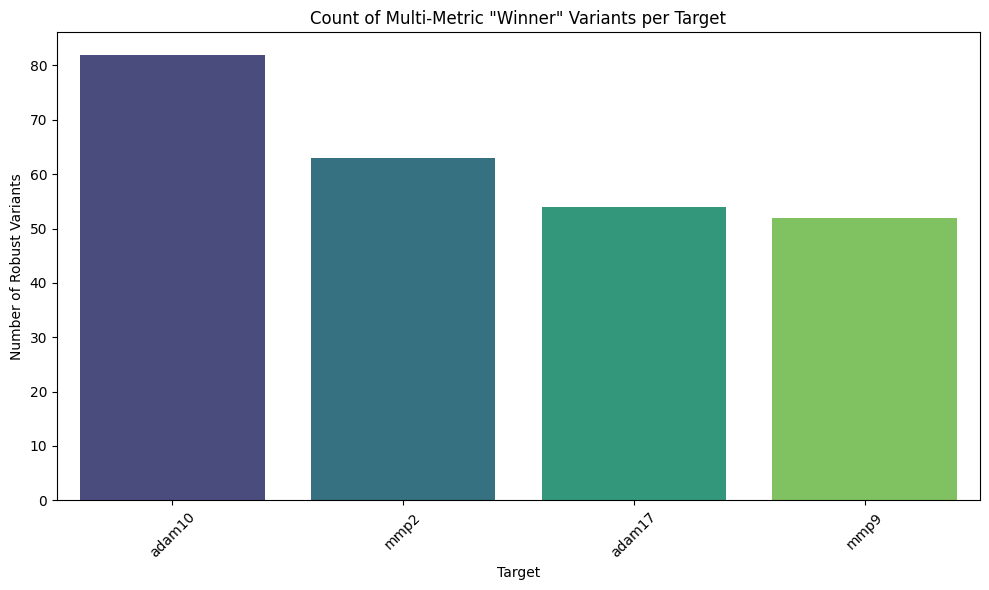

In [91]:
run_consensus_analysis(OUTPUT_FOLDER)

## Intersection Analysis

Inspect each type of analysis for each metric and compile a composit Excel file that only includes variants that are present in the top N for every metric. This is done for each loop and binder analysis

In [92]:
def get_merge_keys(sheet_name):
    """Defines which columns represent the unique identity of a row for merging."""
    base_keys = ['Subgroup', 'Variant']
    
    if sheet_name == 'Best_Raw_Score':
        return base_keys + ['Best_For_Target']
    elif sheet_name == 'Best_Specificity_Global':
        return base_keys + ['Target_of_Interest']
    elif sheet_name == 'Best_Pairwise_Gap':
        return base_keys + ['Primary_Target', 'Secondary_Target']
    elif 'Overall' in sheet_name:
        return base_keys # Overall sheets don't have a specific target context
    return base_keys

def process_intersection(input_folder):
    # Sheet names generated by the previous script
    SHEET_TYPES = [
        'Best_Raw_Score',
        'Best_Specificity_Global',
        'Best_Pairwise_Gap',
        'Top_N_Overall_Best',
        'Bottom_N_Overall_Worst'
    ]

    print(f"--- Starting Intersection Analysis ---")
    print(f"Filtering for variants present in ALL of: {IMPORTANT_METRICS}")

    # Dictionary to hold the final merged dataframes for each sheet type
    final_sheets = {}

    for sheet_name in SHEET_TYPES:
        print(f"\nProcessing Sheet: {sheet_name}")
        
        merged_df = None
        merge_keys = get_merge_keys(sheet_name)
        
        # 1. Load data for each metric
        metric_dfs = []
        
        for metric in IMPORTANT_METRICS:
            filename = f"analysis_results_{metric}.xlsx"
            filepath = os.path.join(input_folder, filename)
            
            if not os.path.exists(filepath):
                print(f"  WARNING: File not found for metric '{metric}' ({filename}). Skipping...")
                continue
                
            try:
                # Load specific sheet
                df = pd.read_excel(filepath, sheet_name=sheet_name)
                
                # Standardize Column Names (some previous scripts might have slight variations)
                # We assume standard structure: Subgroup, Variant, [Context], Rank, [Scores...]
                cols = list(df.columns)
                if len(cols) >= 2:
                    rename_map = {cols[0]: 'Subgroup', cols[1]: 'Variant'}
                    df = df.rename(columns=rename_map)
                
                # Rename 'Rank' to 'Rank_{Metric}' to avoid collision
                if 'Rank' in df.columns:
                    df = df.rename(columns={'Rank': f'Rank_{metric}'})
                
                # Rename Score/Data columns to include Metric name
                # We want to keep Merge Keys as is, but rename everything else
                cols_to_rename = {}
                for col in df.columns:
                    if col not in merge_keys and col != f'Rank_{metric}':
                        cols_to_rename[col] = f"{col}_{metric}"
                
                df = df.rename(columns=cols_to_rename)
                
                metric_dfs.append(df)
                print(f"  Loaded {metric} ({len(df)} rows)")
                
            except ValueError:
                print(f"  Sheet '{sheet_name}' not found in {filename}. Skipping.")
            except Exception as e:
                print(f"  Error loading {filename}: {e}")

        # 2. Perform Intersection (Inner Merge)
        if len(metric_dfs) < len(IMPORTANT_METRICS):
            print("  Skipping merge: Could not load data for all requested metrics.")
            continue
            
        # Start with the first dataframe
        merged_df = metric_dfs[0]
        
        # Merge the rest iteratively (Inner Join = Intersection)
        for i in range(1, len(metric_dfs)):
            merged_df = pd.merge(merged_df, metric_dfs[i], on=merge_keys, how='inner')
            
        if merged_df.empty:
            print("  Result: No overlapping variants found.")
            continue

        print(f"  Result: {len(merged_df)} variants survived the intersection.")

        # 3. Calculate Average Rank
        rank_cols = [f'Rank_{m}' for m in IMPORTANT_METRICS if f'Rank_{m}' in merged_df.columns]
        if rank_cols:
            merged_df['Average_Rank'] = merged_df[rank_cols].mean(axis=1)
            
            # Reorder columns: Keys -> Avg Rank -> Metric 1 Data -> Metric 2 Data
            # Identify score columns associated with each metric
            ordered_cols = merge_keys + ['Average_Rank']
            
            for metric in IMPORTANT_METRICS:
                # Find all columns belonging to this metric
                m_cols = [c for c in merged_df.columns if c.endswith(f"_{metric}")]
                # Sort them so Rank is first
                m_cols.sort(key=lambda x: 0 if 'Rank' in x else 1)
                ordered_cols.extend(m_cols)
                
            merged_df = merged_df[ordered_cols]

        # Store for saving
        final_sheets[sheet_name] = merged_df

    # 4. Save to Excel
    if final_sheets:
        # Create filename based on metrics used
        metrics_str = "_".join(IMPORTANT_METRICS)
        output_filename = f"Intersection_{metrics_str}.xlsx"
        output_path = os.path.join(input_folder, output_filename)
        
        with pd.ExcelWriter(output_path) as writer:
            for sheet_name, df in final_sheets.items():
                df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print(f"\n--- Success ---")
        print(f"Intersection file saved to: {output_path}")

        return output_path
    else:
        print("\nNo data generated.")
        return None

In [93]:
intersection_file = process_intersection(OUTPUT_FOLDER)

--- Starting Intersection Analysis ---
Filtering for variants present in ALL of: ['LpLDDT', 'PAE', 'ipTM']

Processing Sheet: Best_Raw_Score
  Loaded LpLDDT (120 rows)
  Loaded PAE (120 rows)
  Loaded ipTM (163 rows)
  Result: 127 variants survived the intersection.

Processing Sheet: Best_Specificity_Global
  Loaded LpLDDT (122 rows)
  Loaded PAE (120 rows)
  Loaded ipTM (127 rows)
  Result: 66 variants survived the intersection.

Processing Sheet: Best_Pairwise_Gap
  Loaded LpLDDT (362 rows)
  Loaded PAE (361 rows)
  Loaded ipTM (501 rows)
  Result: 246 variants survived the intersection.

Processing Sheet: Top_N_Overall_Best
  Loaded LpLDDT (30 rows)
  Loaded PAE (30 rows)
  Loaded ipTM (33 rows)
  Result: 31 variants survived the intersection.

Processing Sheet: Bottom_N_Overall_Worst
  Loaded LpLDDT (30 rows)
  Loaded PAE (30 rows)
  Loaded ipTM (30 rows)
  Result: 23 variants survived the intersection.

--- Success ---
Intersection file saved to: ../Local/AlphaFoldMetrics\Analysi

## Determining Best Variants to Synthesize

Look at the best varient for the interactions that are most relevant and produce a document with the best ~20 variant along with the reason that they should be ordered

In [94]:
def get_top_n_per_subgroup(df, n):
    """Returns the top N rows for each subgroup."""
    if df.empty: return df
    # Assuming the file is already sorted by Rank from previous scripts
    return df.groupby('Subgroup').head(n)

def build_structural_lookup(folder, keyword):
    """
    Scans raw Excel files for the keyword (e.g., 'pTM').
    Returns a dictionary: { (Subgroup, Variant): Overall_Score }
    """
    print(f"--- Building Structural Lookup ({keyword}) ---")
    lookup = {}
    
    # Find all files matching the keyword in the raw folder
    all_files = glob.glob(os.path.join(folder, "*.xlsx"))
    struct_files = [f for f in all_files if keyword in os.path.basename(f) and "analysis_results" not in f]
    
    if not struct_files:
        print(f"  WARNING: No raw files found containing '{keyword}'. Filter will be skipped.")
        return {}

    for filepath in struct_files:
        try:
            df = pd.read_excel(filepath)
            # Fix merged cells (ffill)
            df.iloc[:, 0] = df.iloc[:, 0].ffill()
            
            # Identify columns
            subgroup_col = df.columns[0]
            variant_col = df.columns[1]
            target_cols = df.columns[2:]
            
            # Clean numeric data
            for col in target_cols:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Calculate Mean Score (Overall Folding)
            df['Struct_Mean'] = df[target_cols].mean(axis=1)
            
            # Populate Dict
            for _, row in df.iterrows():
                key = (row[subgroup_col], row[variant_col])
                lookup[key] = row['Struct_Mean']
                
        except Exception as e:
            print(f"  Error reading {os.path.basename(filepath)}: {e}")
            
    print(f"  Indexed structural scores for {len(lookup)} variants.\n")
    return lookup

def select_variants(input_file):
    if not os.path.exists(input_file):
        print(f"Error: Input file not found at {input_file}")
        return

    print(f"Reading from: {os.path.basename(input_file)}\n")
    
    struct_lookup = {}
    if APPLY_STRUCTURAL_FILTER:
        struct_lookup = build_structural_lookup(INPUT_FOLDER, STRUCTURAL_METRIC_KEY)

    # Storage for selected variants
    # Structure: { (Subgroup, Variant): [List of Reasons] }
    selection_map = {}
    
    # Helper to add variants to our master list
    # Helper to add variants with filtering
    def add_selections(df, reason_tag):
        if df.empty: return
        
        added_count = 0
        skipped_count = 0
        
        for _, row in df.iterrows():
            sub = row['Subgroup']
            var = row['Variant']
            key = (sub, var)
            
            # --- FILTER CHECK ---
            if APPLY_STRUCTURAL_FILTER and struct_lookup:
                # Get score, default to -1 if not found (fails filter)
                score = struct_lookup.get(key, -1.0) 
                
                # Check threshold
                if score < STRUCTURAL_THRESHOLD:
                    skipped_count += 1
                    continue # SKIP THIS VARIANT
            # --------------------

            if key not in selection_map:
                selection_map[key] = []
            selection_map[key].append(reason_tag)
            added_count += 1
            
        # Optional debug print
        if skipped_count > 0:
            print(f"    (Filtered out {skipped_count} variants due to poor structure)")

    # ==========================================
    # 1. High Overall Affinity (Best Generalists)
    # ==========================================
    print(f"Selecting Top {COUNT_PER_CATEGORY} Overall Best...")
    try:
        df_best = pd.read_excel(input_file, sheet_name='Top_N_Overall_Best')
        # Standardize columns just in case
        df_best = df_best.rename(columns={df_best.columns[0]: 'Subgroup', df_best.columns[1]: 'Variant'})
        selected = get_top_n_per_subgroup(df_best, COUNT_PER_CATEGORY) # Can *2 to Grab extra in case some get filtered
        add_selections(selected, "High_Overall_Affinity")
    except Exception as e:
        print(f"  Warning: Could not process High Overall ({e})")

    # ==========================================
    # 2. Low Overall Affinity (Negative Controls)
    # ==========================================
    print(f"Selecting Top {COUNT_PER_CATEGORY} Overall Worst...")
    try:
        df_worst = pd.read_excel(input_file, sheet_name='Bottom_N_Overall_Worst')
        df_worst = df_worst.rename(columns={df_worst.columns[0]: 'Subgroup', df_worst.columns[1]: 'Variant'})
        selected = get_top_n_per_subgroup(df_worst, COUNT_PER_CATEGORY)
        add_selections(selected, "Low_Overall_Affinity")
    except Exception as e:
        print(f"  Warning: Could not process Low Overall ({e})")

    # ==========================================
    # 3. Specific Binders (Target 1 & 2)
    # ==========================================
    try:
        df_spec = pd.read_excel(input_file, sheet_name='Best_Specificity_Global')
        df_spec = df_spec.rename(columns={df_spec.columns[0]: 'Subgroup', df_spec.columns[1]: 'Variant'})
        
        # Target 1
        print(f"Selecting Specific to {TARGET_1}...")
        t1_rows = df_spec[df_spec['Target_of_Interest'] == TARGET_1]
        selected_t1 = get_top_n_per_subgroup(t1_rows, COUNT_PER_CATEGORY)
        add_selections(selected_t1, f"Specific_to_{TARGET_1}")
        
        # Target 2
        print(f"Selecting Specific to {TARGET_2}...")
        t2_rows = df_spec[df_spec['Target_of_Interest'] == TARGET_2]
        selected_t2 = get_top_n_per_subgroup(t2_rows, COUNT_PER_CATEGORY)
        add_selections(selected_t2, f"Specific_to_{TARGET_2}")
        
    except Exception as e:
        print(f"  Warning: Could not process Specificity ({e})")

    # ==========================================
    # 4. Pairwise Winners
    # ==========================================
    try:
        df_pair = pd.read_excel(input_file, sheet_name='Best_Pairwise_Gap')
        df_pair = df_pair.rename(columns={df_pair.columns[0]: 'Subgroup', df_pair.columns[1]: 'Variant'})
        
        # Pair 1: Target 1 vs Pair Neg 1
        print(f"Selecting {TARGET_1} > {PAIR_NEG_1}...")
        p1_rows = df_pair[
            (df_pair['Primary_Target'] == TARGET_1) & 
            (df_pair['Secondary_Target'] == PAIR_NEG_1)
        ]
        selected_p1 = get_top_n_per_subgroup(p1_rows, COUNT_PER_CATEGORY)
        add_selections(selected_p1, f"Better_{TARGET_1}_vs_{PAIR_NEG_1}")
        
        # Pair 2: Target 2 vs Pair Neg 2
        print(f"Selecting {TARGET_2} > {PAIR_NEG_2}...")
        p2_rows = df_pair[
            (df_pair['Primary_Target'] == TARGET_2) & 
            (df_pair['Secondary_Target'] == PAIR_NEG_2)
        ]
        selected_p2 = get_top_n_per_subgroup(p2_rows, COUNT_PER_CATEGORY)
        add_selections(selected_p2, f"Better_{TARGET_2}_vs_{PAIR_NEG_2}")
        
    except Exception as e:
        print(f"  Warning: Could not process Pairwise ({e})")

    # ==========================================
    # 5. Compile Final List
    # ==========================================
    print("\nCompiling Final List...")
    final_data = []
    
    for (subgroup, variant), reasons in selection_map.items():
        # Retrieve structural score for the report (if available)
        struct_score = struct_lookup.get((subgroup, variant), "N/A") if APPLY_STRUCTURAL_FILTER else "N/A"
        
        final_data.append({
            'Subgroup': subgroup,
            'Variant': variant,
            f'{STRUCTURAL_METRIC_KEY}_Score': struct_score,
            'Selection_Count': len(reasons),
            'Reasons': ", ".join(reasons)
        })
    
    if not final_data:
        print("No variants selected. (Check if your PTM threshold is too high!)")
        return

    df_final = pd.DataFrame(final_data)
    
    # Sort for easy reading
    df_final = df_final.sort_values(['Subgroup', 'Selection_Count'], ascending=[True, False])

    # Save
    output_path = os.path.join(os.path.dirname(input_file), f'Final_Ordering_List_{'_'.join(IMPORTANT_METRICS)}.xlsx')
    df_final.to_excel(output_path, index=False)
    
    print(f"Done! Found {len(df_final)} unique variants.")
    print(f"File saved to: {output_path}")

    # Optional: Print summary
    print("\nSummary per Subgroup:")
    print(df_final['Subgroup'].value_counts())

In [95]:
select_variants(intersection_file)

Reading from: Intersection_LpLDDT_PAE_ipTM.xlsx

--- Building Structural Lookup (ApTM) ---
  Indexed structural scores for 130 variants.

Selecting Top 3 Overall Best...
Selecting Top 3 Overall Worst...
    (Filtered out 2 variants due to poor structure)
Selecting Specific to adam17...
Selecting Specific to mmp9...
Selecting adam17 > adam10...
    (Filtered out 2 variants due to poor structure)
Selecting mmp9 > mmp2...

Compiling Final List...
Done! Found 39 unique variants.
File saved to: ../Local/AlphaFoldMetrics\Analysis_Results\Final_Ordering_List_LpLDDT_PAE_ipTM.xlsx

Summary per Subgroup:
Subgroup
ab    15
ef    14
c     10
Name: count, dtype: int64
